# Classification des œuvres de Zola et d'autres naturalistes

## Expérience avec concervation des noms propres

## 1. Importation des bibliothèques

In [1]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Représentation textuelle
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Pipelines et validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Toutes les bibliothèques sont chargées.")

Toutes les bibliothèques sont chargées.


## 2. Normalisation des apostrophes

Les textes ayant été préalablement nettoyés, certaines apostrophes ont
disparu. Cette étape restaure les contractions les plus fréquentes à partir
d'un dictionnaire de correspondances.

N.b: Les formes `dune` et `lune` sont respectivement interprétées comme `d'une`
et `l'une`. Ce choix repose sur l'hypothèse que les occurrences des noms
communs *dune* et *lune* sont minoritaires dans le corpus étudié.

In [2]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dune": "d'une", #je prend le parti de mettre d'apostrophe mais il y a un risque de confusion avec "d'une" (de une) et "dune" (la dune) 
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "doù": "d'où",
    "dautres": "d'autres",
    "damour": "d'amour",
    "dargent": "d'argent",
    "despoir": "d'espoir",
    "den": "d'en",
    "desprit": "d'esprit",
    'deau': "d'eau",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",
    'lavenir': "l'avenir",
    "laffaire": "l'affaire",
    "loreille": "l'oreille",
    "lavocat": "l'avocat",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",
    "mavait": "m'avait",
    
    "daller": "d'aller",
    "lappartement": "l'appartement",
    "lhuile": "l'huile",
    "mest": "m'est",
    "dhonneur": "d'honneur",
    "dici": "d'ici",
    "neût": "n'eût",
    "sécrie": "s'écrie",
    "ce quelle": "ce qu'elle",
    "ten": "t'en",
    "dhenriette": "d'Henriette",
    "lart": "l'art",
    "quau": "qu'au",
    "quaux": "qu'aux",
    "dautre": "d'autre",
    "dautres": "d'autres",
    "navais": "n'avais",
    "navions": "n'avions",
    "sagit": "s'agit",
    
}

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


def restaurer_apostrophes(texte):
    """Restaure certaines apostrophes supprimées avec une forte confiance."""

    remplacements_tries = sorted(
        REMPLACEMENTS_APOSTROPHES.items(),
        key=lambda element: len(element[0]),
        reverse=True
    )

    for forme_nettoyee, forme_corrigee in remplacements_tries:
        motif = rf"\b{re.escape(forme_nettoyee)}\b"

        texte = re.sub(
            motif,
            lambda correspondance: adapter_casse(
                correspondance.group(0),
                forme_corrigee
            ),
            texte,
            flags=re.IGNORECASE
        )

    return texte

## 3. Segmentation des fichiers en blocs de 3 lignes

In [3]:
def segmenter_en_paquets(texte, taille_paquet=3):
    lignes = texte.splitlines()
    lignes = [ligne.strip() for ligne in lignes if ligne.strip()]

    paquets = []

    for i in range(0, len(lignes), taille_paquet):
        paquet = " ".join(lignes[i:i + taille_paquet])

        if paquet:
            paquets.append(paquet)

    return paquets


def determiner_label(nom_fichier):
    if nom_fichier.endswith("clean.txt"):
        return "Zola"

    return "naturaliste"


def construire_dataframe(liste_fichiers):
    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        label = determiner_label(nom_fichier)

        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = fichier.read()

        # Restauration appliquée aux deux corpus
        texte = restaurer_apostrophes(texte)

        blocs = segmenter_en_paquets(
            texte,
            taille_paquet=3
        )

        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })

    return pd.DataFrame(donnees)


chemin_dossier = "Z_vs_N"

liste_fichiers = sorted(
    glob.glob(
        os.path.join(chemin_dossier, "*.txt")
    )
)

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

random.seed(1)
random.shuffle(liste_fichiers)

liste_train = liste_fichiers[:40]
liste_test = liste_fichiers[40:]

df_train = construire_dataframe(liste_train)
df_test = construire_dataframe(liste_test)

print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())

print("\nTEST")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())

Nombre de fichiers trouvés : 49

TRAIN
label
Zola           36820
naturaliste    25492
Name: count, dtype: int64
Nombre d'œuvres : 40

TEST
label
Zola           9518
naturaliste    5060
Name: count, dtype: int64
Nombre d'œuvres : 9


## 4. Vérification de la composition des corpus

Cette section vérifie le nombre de segments, les œuvres présentes et leur
répartition entre les classes dans les corpus d'entraînement et de test.

In [4]:
print("Textes dans le train")
print(len(df_train))

sources_par_label = (
    df_train.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nTextes dans le test")
print(len(df_test))
        
sources_par_label = (
    df_test.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Textes dans le train
62312
------------------------------
Sources par label :

Zola :
  - 1873_3_Le_ventre_de_Paris._clean.txt
  - 1888_16_Le_reve._clean.txt
  - 1882_10_Pot-bouille._clean.txt
  - 1876_6_Son_Excellence_Eugene_Rougon._clean.txt
  - 1887_15_La_terre._clean.txt
  - 1884_12_La_joie_de_vivre._clean.txt
  - 1893_20_Le_docteur_Pascal._clean.txt
  - 1885_13_Germinal._clean.txt
  - 1883_11_Au_Bonheur_des_dames._clean.txt
  - 1874_4_La_conquete_de_Plassans._clean.txt
  - 1892_19_La_debacle._clean.txt
  - 1891_18_L_argent._clean.txt
  - 1871_1_La_fortune_des_Rougon._clean.txt
  - 1871_2_La_curee._clean.txt
  - 1877_7_L_assommoir._clean.txt
  - 1886_14_L_oeuvre._clean.txt

naturaliste :
  - malheur d'Henriette Gérard.txt
  - Amis de la nature.txt
  - En route.txt
  - rois_en_exil.txt
  - le_Nabab.txt
  - Germinie Lacerteux.txt
  - L'education_sentimentale.txt
  - Confessions de Sylvius.txt
  - soutien_de_famille.txt
  - Paule Méré.txt
  - Mont Oriol.txt
  - Barbier de Paris.txt
  

## 5. Représentation TF-IDF avec conservation des noms propres

In [6]:
# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]

X_test = df_test["texte"].fillna("")
y_test = df_test["label"]


# ============================================================
# # Construction de la représentation TF-IDF commune aux trois modèles
# ============================================================


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)

Dimensions du train : (62312, 10000)
Dimensions du test  : (14578, 10000)


## 6. Validation croisée groupée et sélection du modèle

Les trois modèles sont évalués sur les mêmes plis de
`StratifiedGroupKFold`. Les segments d'une même œuvre restent dans un seul
groupe afin d'éviter qu'une œuvre apparaisse simultanément dans
l'entraînement et la validation.

Le critère principal de sélection est le F1 macro moyen.

In [7]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Les plis sont calculés une seule fois pour garantir la même
# séparation pour tous les modèles.
plis = list(cv.split(X, Y, groups=groups))


modeles = {
    "Naive Bayes": Pipeline([
        ("tfidf", vectorizer),
        ("clf", MultinomialNB(alpha=1.0))
    ]),

    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(
            n_components=100,
            random_state=42
        )),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
            solver="svd"
        ))
    ])
}

resultats = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele,
        X,
        Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        n_jobs=1  # mettre -1 uniquement si la mémoire disponible le permet
    )

    resultats.append({
        "modèle": nom,
        "F1 macro moyen": scores["test_f1_macro"].mean(),
        "écart-type F1": scores["test_f1_macro"].std(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

comparaison_cv = (
    pd.DataFrame(resultats)
    .sort_values("F1 macro moyen", ascending=False)
    .reset_index(drop=True)
)

for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])

    intersection = sources_train & sources_validation

    print(
        f"Pli {numero} : "
        f"{len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )

    assert len(intersection) == 0
    
display(comparaison_cv)

Pli 1 : 31 œuvres train, 9 œuvres validation, intersection = 0
Pli 2 : 32 œuvres train, 8 œuvres validation, intersection = 0
Pli 3 : 33 œuvres train, 7 œuvres validation, intersection = 0
Pli 4 : 32 œuvres train, 8 œuvres validation, intersection = 0
Pli 5 : 32 œuvres train, 8 œuvres validation, intersection = 0


,modèle,F1 macro moyen,écart-type F1,accuracy moyenne,F1 entraînement
0,Régression logistique,0.807838,0.037945,0.815414,0.945767
1,Naive Bayes,0.743335,0.068347,0.761669,0.897636
2,LDA,0.719444,0.047283,0.737030,0.798357


## 7. Entraînement final et évaluation sur le corpus de test

### 7.1 Naive Bayes multinomial

              precision    recall  f1-score   support

        Zola       0.85      0.86      0.85      9518
 naturaliste       0.73      0.71      0.72      5060

    accuracy                           0.81     14578
   macro avg       0.79      0.79      0.79     14578
weighted avg       0.81      0.81      0.81     14578

[[8178 1340]
 [1453 3607]]


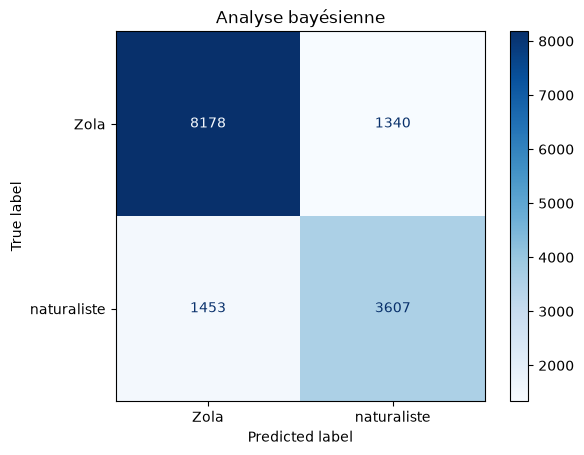

In [8]:
modele_bayes = MultinomialNB(alpha=1)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

### 7.2 Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.906     0.843     0.873      9518
 naturaliste      0.738     0.836     0.784      5060

    accuracy                          0.840     14578
   macro avg      0.822     0.839     0.829     14578
weighted avg      0.848     0.840     0.842     14578

Matrice de confusion :
[[8020 1498]
 [ 832 4228]]


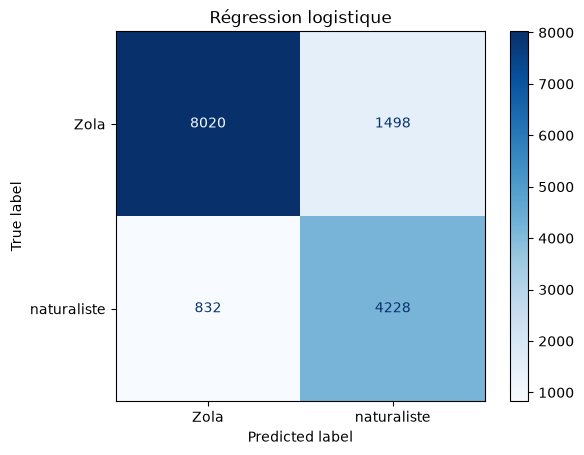

In [9]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

### 7.3 Analyse discriminante linéaire après réduction SVD

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.147
              precision    recall  f1-score   support

        Zola      0.835     0.858     0.846      9518
 naturaliste      0.718     0.682     0.699      5060

    accuracy                          0.797     14578
   macro avg      0.777     0.770     0.773     14578
weighted avg      0.794     0.797     0.795     14578

Matrice de confusion :
[[8163 1355]
 [1611 3449]]


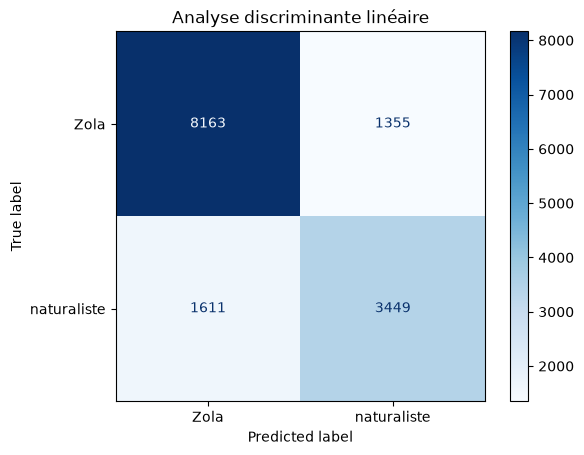

In [10]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


## 8. Comparaison des performances sur le corpus de test

Les résultats du corpus de test sont présentés après la sélection du modèle
par validation croisée. Ils constituent une évaluation complémentaire.

In [11]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

print("\nComparaison des modèles sur le jeu de test :")

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


Comparaison des modèles sur le jeu de test :


,modèle,accuracy,f1_macro
0,Régression logistique,0.840170,0.828571
1,Analyse bayésienne,0.808410,0.787520
2,Analyse discriminante linéaire,0.796543,0.772784


## 9. Évaluation finale au niveau des œuvres

Les probabilités des segments appartenant à une même œuvre sont moyennées
afin d'obtenir une prédiction unique par œuvre.

In [12]:
probabilites = modele_logistique.predict_proba(
    X_test_tfidf
)

classe_zola = list(
    modele_logistique.classes_
).index("Zola")

evaluation_oeuvres = df_test[
    ["source", "label"]
].copy()

evaluation_oeuvres["probabilite_zola"] = (
    probabilites[:, classe_zola]
)

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=(
            "probabilite_zola",
            "mean"
        )
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         4
 naturaliste      1.000     1.000     1.000         5

    accuracy                          1.000         9
   macro avg      1.000     1.000     1.000         9
weighted avg      1.000     1.000     1.000         9



,source,label_reel,probabilite_zola,prediction
0,1875_5_La_faute_de_l_abbe_Mouret._clean.txt,Zola,0.740264,Zola
1,1878_8_Une_page_d_amour._clean.txt,Zola,0.672844,Zola
2,1880_9_Nana._clean.txt,Zola,0.736188,Zola
3,1890_17_La_bete_humaine._clean.txt,Zola,0.763613,Zola
4,Charles Demailly.txt,naturaliste,0.232875,naturaliste
5,En ménage.txt,naturaliste,0.335568,naturaliste
6,Frères_Zemganno.txt,naturaliste,0.249648,naturaliste
7,Georgette.txt,naturaliste,0.223562,naturaliste
8,Le_Pere_Goriot.txt,naturaliste,0.284735,naturaliste


## 10. Interprétation des modèles à partir du corpus d'entraînement

Cette section examine les paramètres appris par les modèles, sans tenir
compte de la fréquence des termes dans le corpus de test.

### 10.1 Termes caractéristiques selon Naive Bayes

In [13]:
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
rougon                    4.794
mouret                    4.406
gervaise                  4.385
saccard                   4.353
coupeau                   4.253
pauline                   4.211
denise                    4.088
étienne                   4.024
buteau                    4.004
octave                    3.995
florent                   3.888
faujas                    3.876
plassans                  3.781
chanteau                  3.779
lisa                      3.766
josserand                 3.735
renée                     3.670
claude                    3.625
abbé faujas               3.610
silvère                   3.603
clorinde                  3.572
maurice                   3.566
maheu                     3.521
lantier                   3.488
sandoz                    3.469
lorilleux                 3.461
fouan                     3.455
macquart                  3.451
duveyrier          

### 10.2 Coefficients de la régression logistique

In [14]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
rougon                         -9.5969
saccard                        -8.7017
mouret                         -8.0243
pauline                        -6.7854
claude                         -6.3265
lorsque                        -6.3132
gervaise                       -6.0334
octave                         -5.8579
renée                          -5.7722
maxime                         -5.6359
plassans                       -5.5772
denise                         -5.5632
empereur                       -5.3828
coupeau                        -5.3264
ça                             -5.2980
qu elle                        -5.2622
jean                           -5.2030
florent                        -5.2007
lazare                         -5.1044
étienne                        -5.0557
félicité                       -4.9697
buteau                         -4.9229
hein                           -4.9206
maurice                  

## 11. Analyse post-hoc du corpus de test

Cette section examine les termes effectivement présents dans le corpus de
test. Elle est uniquement interprétative et n'est pas utilisée pour
modifier le prétraitement, sélectionner le modèle ou régler ses
hyperparamètres.

### 11.1 Présence et poids TF-IDF des termes dans le test

In [15]:
# Utilisation du TF-IDF commun
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9705


### 11.2 Termes discriminants de Naive Bayes présents dans le test

In [16]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}")


Termes présents dans le test les plus caractéristiques de Zola :
rougon                    score=4.794  extraits=3
mouret                    score=4.406  extraits=170
gervaise                  score=4.385  extraits=1
pauline                   score=4.211  extraits=81
denise                    score=4.088  extraits=1
étienne                   score=4.024  extraits=1
octave                    score=3.995  extraits=3
plassans                  score=3.781  extraits=15
lisa                      score=3.766  extraits=15
claude                    score=3.625  extraits=2
maurice                   score=3.566  extraits=3
lantier                   score=3.488  extraits=10
macquart                  score=3.451  extraits=1
boche                     score=3.343  extraits=1
miette                    score=3.151  extraits=3
lazare                    score=3.143  extraits=12
prussiens                 score=3.138  extraits=4
nana                      score=3.100  extraits=778
maxime                   

### 11.3 Contribution lexicale globale dans le corpus de test

L'indicateur ci-dessous combine le caractère discriminant appris par
Naive Bayes avec le poids TF-IDF total du terme dans le corpus de test.

Il s'agit d'un indicateur descriptif global. Il ne représente pas une
explication locale exacte de chaque prédiction.

In [17]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)


print(contributions_zola[["terme", "contribution_test"]])
print(contributions_naturalistes[["terme", "contribution_test"]])

           terme  contribution_test
6086        nana         518.947609
2787        elle         226.339002
3349      eugène         159.336785
9745          ça         139.323753
9871       était         127.690157
7321     qu elle         123.691410
552        avait         114.042782
5994      mouret         106.842652
4502          la          93.422786
5362     lorsque          75.587600
3951        hein          69.602827
5123         les          65.797717
7317          qu          63.155545
5355      lorsqu          61.931776
2798  elle avait          57.747467
6698     pauline          57.408527
4217         ils          56.858617
5531   madame de          56.760728
1708        cria          54.402899
2888  elle était          53.942977
9072        très          53.624988
3352         eut          51.039225
5454          là          48.331352
4084    il avait          48.113994
5713      marthe          47.297999
9162     un coup          46.898911
6012     murmura          46

## 13. Conclusion
